# ⚽ Predict the FIFA World Cup 2026

## 📖 Background

The 2026 FIFA World Cup is one of the biggest sporting events in the world, hosted across the United States, Canada, and Mexico. For the first time, the tournament expands to 48 teams, producing 104 matches across the group stage and knockout rounds.

Using machine learning, historical statistics, and soccer domain knowledge, predict match scores, corners, and cards for every fixture. You must submit all your predictions before a single ball is kicked.

The scoring system rewards precision: an exact scoreline earns maximum points, while close predictions still earn partial credit. Later rounds carry score multipliers, so a strong model that holds up in the knockout stages can leapfrog the competition. The challenge is designed to be difficult enough that no one can achieve a perfect score—even with AI assistance—but accessible enough that any data enthusiast can participate and score points.

## 💾 The data

You have access to the following files:

#### `data/group_fixtures.csv` — all 72 group stage matches
| Variable | Description |
|---|---|
| `match_id` | Unique match identifier |
| `group` | Group letter (A–L) |
| `home_team` | Home team name |
| `away_team` | Away team name |
| `date` | Match date (UTC) |
| `venue` | Stadium and city |

#### `data/knockout_slots.csv` — all 32 knockout round slots
| Variable | Description |
|---|---|
| `match_id` | Unique match identifier |
| `round` | Round name (e.g. `Quarter-final`) |
| `multiplier` | Score multiplier for this round |
| `slot_home` | Description of the home team slot (e.g. `Winner Group A`) |
| `slot_away` | Description of the away team slot |

| Variable | Description |
|---|---|

You may also bring in any external data—FIFA rankings, historical match results, player statistics—to build your predictions.

In [99]:
import pandas as pd

group_fixtures = pd.read_csv('data/group_fixtures.csv')
group_fixtures.head()

,match_id,group,home_team,away_team,date_utc,venue
0,1,A,Mexico,South Africa,2026-06-11T19:00:00Z,"Estadio Azteca, Mexico City"
1,2,A,South Korea,UEFA Playoff D,2026-06-12T02:00:00Z,"Estadio Akron, Guadalajara"
2,3,B,Canada,UEFA Playoff A,2026-06-12T19:00:00Z,"BMO Field, Toronto"
3,4,D,USA,Paraguay,2026-06-13T01:00:00Z,"SoFi Stadium, Los Angeles"
4,5,D,Australia,UEFA Playoff C,2026-06-13T04:00:00Z,"BC Place, Vancouver"


In [100]:
knockout_slots = pd.read_csv('data/knockout_slots.csv')
knockout_slots

,match_id,round,multiplier,date_utc,venue,slot_home,slot_away
0,73,Round of 32,1,2026-06-28T19:00:00Z,"SoFi Stadium, Los Angeles",Runner-up Group A,Runner-up Group B
1,74,Round of 32,1,2026-06-29T17:00:00Z,"NRG Stadium, Houston",Winner Group C,Runner-up Group F
2,75,Round of 32,1,2026-06-29T20:30:00Z,"Gillette Stadium, Boston",Winner Group E,Best 3rd (Groups A/B/C/D/F)
3,76,Round of 32,1,2026-06-30T01:00:00Z,"Estadio BBVA, Monterrey",Winner Group F,Runner-up Group C
4,77,Round of 32,1,2026-06-30T17:00:00Z,"AT&T Stadium, Dallas",Runner-up Group E,Runner-up Group I
5,78,Round of 32,1,2026-06-30T21:00:00Z,"MetLife Stadium, East Rutherford",Winner Group I,Best 3rd (Groups C/D/F/G/H)
6,79,Round of 32,1,2026-07-01T01:00:00Z,"Estadio Azteca, Mexico City",Winner Group A,Best 3rd (Groups C/E/F/H/I)
7,80,Round of 32,1,2026-07-01T16:00:00Z,"Mercedes-Benz Stadium, Atlanta",Winner Group L,Best 3rd (Groups E/H/I/J/K)
8,81,Round of 32,1,2026-07-01T20:00:00Z,"Lumen Field, Seattle",Winner Group G,Best 3rd (Groups A/E/H/I/J)
9,82,Round of 32,1,2026-07-02T00:00:00Z,"Levi's Stadium, Santa Clara",Winner Group D,Best 3rd (Groups B/E/F/I/J)


## 💪 Competition challenge

The 2026 World Cup has two phases:

- **Group stage** (matches 1–72): The 48 teams are split into 12 groups of 4. Every team plays the other 3 teams in their group once. The best teams from each group advance to the next phase.
- **Knockout stage** (matches 73–104): Single-elimination rounds — Round of 32, Round of 16, Quarter-finals, Semi-finals, and the Final. Lose once and you're out. Crucially, the two teams playing in each knockout match are not known in advance: they depend on who qualified from the group stage.

Submit predictions for **every match** in both phases. For each match you need to predict:

1. **Score** — the exact final scoreline (e.g. `2-1` means the home team scores 2, the away team scores 1). For knockout matches, the score is the result after 90 minutes and extra time — the penalty shootout is not included.
2. **Corners** — the number of corner kicks awarded in the match
3. **Yellow cards** — the number of yellow cards shown in the match
4. **Red cards** — the number of red cards shown in the match

For **group stage** matches, also predict:
- **Winning team** — which team wins the individual match (use `home`, `away`, or `draw`)

For **knockout round** matches, also predict:
- **Matchup** — which two teams you predict will be playing in that slot. Because the bracket is determined by group stage results, you need to predict which teams advance far enough to meet in each round.
- **Match winner** — which team wins the match (use `home` or `away`)
- **Penalties** — whether the match goes to a penalty shootout (`True` or `False`)

### Scoring system

| Category | Condition | Points |
|---|---|---|
| Score | Exact scoreline | 25 |
| Score | Correct goal difference, wrong score | 10 |
| Score | Correct total goals, wrong score | 10 |
| Corners | Exact number | 10 |
| Corners | Off by 2 | 5 |
| Yellow cards | Exact number | 10 |
| Yellow cards | Off by 1 | 5 |
| Red cards | Exact number | 5 |
| Winning team *(group stage only)* | Correct | 40 |
| Matchup *(knockout only)* | Both teams correct | 20 |
| Matchup *(knockout only)* | One team correct | 10 |
| Match winner *(knockout only)* | Correct | 20 |
| Penalties *(knockout only)* | Correct | 5 |

All points for a match are multiplied by the round factor:

| Round | Multiplier |
|---|---|
| Group stage | ×1 |
| Round of 32 | ×1 |
| Round of 16 | ×2 |
| Quarter-final | ×4 |
| Semi-final | ×8 |
| Third-place playoff | ×8 |
| Final | ×16 |

## 🗓️ Group stage predictions

Fill in your predictions for all 72 group stage matches below.

In [101]:
group_predictions = group_fixtures.copy()

# Fill in your predictions for each match
# Example (match 1 — Mexico vs South Africa): predicted_home_goals=2, predicted_away_goals=1, corners=9, yellow_cards=3, red_cards=0, winning_team='home'
group_predictions['predicted_home_goals'] = None   # e.g. 2
group_predictions['predicted_away_goals'] = None   # e.g. 1
group_predictions['corners']              = None   # e.g. 9
group_predictions['yellow_cards']         = None   # e.g. 3
group_predictions['red_cards']            = None   # e.g. 0
group_predictions['winning_team']         = None   # "home", "away", or "draw"

group_predictions

,match_id,group,home_team,away_team,date_utc,venue,predicted_home_goals,predicted_away_goals,corners,yellow_cards,red_cards,winning_team
0,1,A,Mexico,South Africa,2026-06-11T19:00:00Z,"Estadio Azteca, Mexico City",None,None,None,None,None,None
1,2,A,South Korea,UEFA Playoff D,2026-06-12T02:00:00Z,"Estadio Akron, Guadalajara",None,None,None,None,None,None
2,3,B,Canada,UEFA Playoff A,2026-06-12T19:00:00Z,"BMO Field, Toronto",None,None,None,None,None,None
3,4,D,USA,Paraguay,2026-06-13T01:00:00Z,"SoFi Stadium, Los Angeles",None,None,None,None,None,None
4,5,D,Australia,UEFA Playoff C,2026-06-13T04:00:00Z,"BC Place, Vancouver",None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...
67,68,L,Croatia,Ghana,2026-06-27T21:00:00Z,"Lincoln Financial Field, Philadelphia",None,None,None,None,None,None
68,69,K,Colombia,Portugal,2026-06-27T23:30:00Z,"Hard Rock Stadium, Miami",None,None,None,None,None,None
69,70,K,FIFA Playoff 1,Uzbekistan,2026-06-27T23:30:00Z,"Mercedes-Benz Stadium, Atlanta",None,None,None,None,None,None
70,71,J,Algeria,Austria,2026-06-28T02:00:00Z,"GEHA Field at Arrowhead Stadium, Kansas City",None,None,None,None,None,None


## 🏆 Knockout stage predictions

For knockout matches you also predict **which teams are playing**. Fill in the team names based on your group stage predictions, then add your match predictions.

In [102]:
knockout_predictions = knockout_slots.copy()

# Fill in your predictions for each knockout match
# Example (match 73 — Round of 32): predicted_home_team='Brazil', predicted_away_team='France', predicted_home_goals=1, predicted_away_goals=0, corners=8, yellow_cards=2, red_cards=0, match_winner='home', penalties=False
knockout_predictions['predicted_home_team']  = None   # e.g. "Brazil"
knockout_predictions['predicted_away_team']  = None   # e.g. "France"
knockout_predictions['predicted_home_goals'] = None   # e.g. 1
knockout_predictions['predicted_away_goals'] = None   # e.g. 0
knockout_predictions['corners']              = None   # e.g. 8
knockout_predictions['yellow_cards']         = None   # e.g. 2
knockout_predictions['red_cards']            = None   # e.g. 0
knockout_predictions['match_winner']         = None   # "home" or "away"
knockout_predictions['penalties']            = None   # True or False

knockout_predictions

,match_id,round,multiplier,date_utc,venue,slot_home,slot_away,predicted_home_team,predicted_away_team,predicted_home_goals,predicted_away_goals,corners,yellow_cards,red_cards,match_winner,penalties
0,73,Round of 32,1,2026-06-28T19:00:00Z,"SoFi Stadium, Los Angeles",Runner-up Group A,Runner-up Group B,None,None,None,None,None,None,None,None,None
1,74,Round of 32,1,2026-06-29T17:00:00Z,"NRG Stadium, Houston",Winner Group C,Runner-up Group F,None,None,None,None,None,None,None,None,None
2,75,Round of 32,1,2026-06-29T20:30:00Z,"Gillette Stadium, Boston",Winner Group E,Best 3rd (Groups A/B/C/D/F),None,None,None,None,None,None,None,None,None
3,76,Round of 32,1,2026-06-30T01:00:00Z,"Estadio BBVA, Monterrey",Winner Group F,Runner-up Group C,None,None,None,None,None,None,None,None,None
4,77,Round of 32,1,2026-06-30T17:00:00Z,"AT&T Stadium, Dallas",Runner-up Group E,Runner-up Group I,None,None,None,None,None,None,None,None,None
5,78,Round of 32,1,2026-06-30T21:00:00Z,"MetLife Stadium, East Rutherford",Winner Group I,Best 3rd (Groups C/D/F/G/H),None,None,None,None,None,None,None,None,None
6,79,Round of 32,1,2026-07-01T01:00:00Z,"Estadio Azteca, Mexico City",Winner Group A,Best 3rd (Groups C/E/F/H/I),None,None,None,None,None,None,None,None,None
7,80,Round of 32,1,2026-07-01T16:00:00Z,"Mercedes-Benz Stadium, Atlanta",Winner Group L,Best 3rd (Groups E/H/I/J/K),None,None,None,None,None,None,None,None,None
8,81,Round of 32,1,2026-07-01T20:00:00Z,"Lumen Field, Seattle",Winner Group G,Best 3rd (Groups A/E/H/I/J),None,None,None,None,None,None,None,None,None
9,82,Round of 32,1,2026-07-02T00:00:00Z,"Levi's Stadium, Santa Clara",Winner Group D,Best 3rd (Groups B/E/F/I/J),None,None,None,None,None,None,None,None,None


## ✅ Checklist before publishing into the competition

- Rename your workspace to make it descriptive of your work. N.B. you should leave the notebook name as `notebook.ipynb`.
- Remove redundant cells like the judging criteria, so the workbook is focused on your predictions.
- Make sure all prediction cells are filled in—`None` values will score 0 points.
- Check that all cells run without error.
- Make sure your workbook is published before **June 10, 2026 at 09:00 UTC**.

## ⏳ Time is ticking. Good luck!

In [131]:
print(group_fixtures.columns.tolist())
print()
print(knockout_slots.columns.tolist())

['match_id', 'group', 'home_team', 'away_team', 'date_utc', 'venue']

['match_id', 'round', 'multiplier', 'date_utc', 'venue', 'slot_home', 'slot_away']


In [103]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import json
import re
from pathlib import Path
from collections import Counter
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier, XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [104]:
# ============================================================
# CELL 2 — LOAD DATA
# ============================================================

ROOT = Path("/work/files/workspace")
DATA_DIR = ROOT / "data"

matches = pd.read_csv(ROOT / "international_matches.csv")
elo = pd.read_csv(ROOT / "eloratings.csv")

fifa_2023 = pd.read_csv(ROOT / "fifa_ranking-2023-07-20.csv")
fifa_2024a = pd.read_csv(ROOT / "fifa_ranking-2024-04-04.csv")
fifa_2024b = pd.read_csv(ROOT / "fifa_ranking-2024-06-20.csv")

former_names = pd.read_csv(ROOT / "former_names.csv")
shootouts = pd.read_csv(ROOT / "shootouts.csv")
goalscorers = pd.read_csv(ROOT / "goalscorers.csv")

group_fixtures = pd.read_csv(DATA_DIR / "group_fixtures.csv")
knockout_slots = pd.read_csv(DATA_DIR / "knockout_slots.csv")

with open(ROOT / "annex_c.json", "r") as f:
    annex_c = json.load(f)

print("Loaded.")
print(matches.shape, elo.shape, group_fixtures.shape, knockout_slots.shape, len(annex_c))

Loaded.
(23921, 25) (6678, 4) (72, 6) (32, 7) 495


In [105]:
# ============================================================
# CELL 3 — TEAM NAME NORMALIZATION
# ============================================================

NAME_MAP = {
    "USA": "United States",
    "Cabo Verde": "Cape Verde",
    "Côte d'Ivoire": "Ivory Coast",
    "Bosnia and Herzegovina": "Bosnia-Herzegovina",
    "Czech Republic": "Czechia",
    "DR Congo": "Democratic Republic of Congo",
    "Iran": "IR Iran",
    "South Korea": "Korea Republic",
    "Curaçao": "Curacao",
    "Türkiye": "Turkey"
}

EXTRA_ELO_MAP = {
    "China PR": "China",
    "Chinese Taipei": "Taiwan",
    "Korea DPR": "North Korea",
    "Kyrgyz Republic": "Kyrgyzstan",
    "Republic of Ireland": "Ireland",
    "Congo DR": "Democratic Republic of Congo",
    "St. Kitts and Nevis": "Saint Kitts and Nevis",
    "St. Lucia": "Saint Lucia",
    "St. Vincent and the Grenadines": "Saint Vincent and the Grenadines",
    "São Tomé and Príncipe": "Sao Tome and Principe",
    "Timor-Leste": "East Timor"
}

ALL_NAME_MAP = {}
ALL_NAME_MAP.update(NAME_MAP)
ALL_NAME_MAP.update(EXTRA_ELO_MAP)

def clean_team_series(s):
    return (
        s.astype(str)
        .str.replace("\xa0", " ", regex=False)
        .str.strip()
        .replace(ALL_NAME_MAP)
    )

for col in ["home_team", "away_team"]:
    matches[col] = clean_team_series(matches[col])

elo["team"] = clean_team_series(elo["team"])

for df in [fifa_2023, fifa_2024a, fifa_2024b]:
    df["country_full"] = clean_team_series(df["country_full"])

for col in ["home_team", "away_team"]:
    group_fixtures[col] = clean_team_series(group_fixtures[col])

PLAYOFF_REPLACEMENTS = {
    "UEFA Playoff A": "Bosnia-Herzegovina",
    "UEFA Playoff B": "Sweden",
    "UEFA Playoff C": "Turkey",
    "UEFA Playoff D": "Czechia",
    "FIFA Playoff 1": "Democratic Republic of Congo",
    "FIFA Playoff 2": "Iraq"
}

group_fixtures = group_fixtures.replace(PLAYOFF_REPLACEMENTS)

print("Names normalized.")

Names normalized.


In [106]:
# ============================================================
# CELL 4 — DATE PARSING
# ============================================================

matches["date"] = pd.to_datetime(matches["date"], errors="coerce")
elo["date"] = pd.to_datetime(elo["date"], format="mixed", errors="coerce")
shootouts["date"] = pd.to_datetime(shootouts["date"], errors="coerce")

for df in [fifa_2023, fifa_2024a, fifa_2024b]:
    df["rank_date"] = pd.to_datetime(df["rank_date"], errors="coerce")

fifa_all = pd.concat([fifa_2023, fifa_2024a, fifa_2024b], ignore_index=True)
fifa_all = fifa_all.drop_duplicates().sort_values("rank_date").reset_index(drop=True)

matches = matches.sort_values("date").reset_index(drop=True)
elo = elo.sort_values("date").reset_index(drop=True)

print(matches["date"].isna().sum(), elo["date"].isna().sum(), shootouts["date"].isna().sum())

0 0 0


In [107]:
# ============================================================
# CELL 5 — LEAKAGE-SAFE ELO MERGE
# ============================================================

home_elo = elo.rename(columns={
    "team": "home_team",
    "rating": "home_elo",
    "change": "home_elo_change"
})

matches = pd.merge_asof(
    matches.sort_values("date"),
    home_elo.sort_values("date"),
    on="date",
    by="home_team",
    direction="backward"
)

away_elo = elo.rename(columns={
    "team": "away_team",
    "rating": "away_elo",
    "change": "away_elo_change"
})

matches = pd.merge_asof(
    matches.sort_values("date"),
    away_elo.sort_values("date"),
    on="date",
    by="away_team",
    direction="backward"
)

print("Missing home Elo:", matches["home_elo"].isna().sum())
print("Missing away Elo:", matches["away_elo"].isna().sum())

Missing home Elo: 666
Missing away Elo: 815


In [108]:
# ============================================================
# CELL 6 — TARGET + ORIGINAL FEATURES
# ============================================================

def get_result(row):
    if row["home_team_score"] > row["away_team_score"]:
        return 2
    elif row["home_team_score"] < row["away_team_score"]:
        return 0
    else:
        return 1

matches["target"] = matches.apply(get_result, axis=1)

matches["elo_diff"] = matches["home_elo"] - matches["away_elo"]
matches["elo_sum"] = matches["home_elo"] + matches["away_elo"]

matches["rank_diff"] = matches["away_team_fifa_rank"] - matches["home_team_fifa_rank"]
matches["points_diff"] = matches["home_team_total_fifa_points"] - matches["away_team_total_fifa_points"]

matches["attack_diff"] = matches["home_team_mean_offense_score"] - matches["away_team_mean_offense_score"]
matches["midfield_diff"] = matches["home_team_mean_midfield_score"] - matches["away_team_mean_midfield_score"]
matches["defense_diff"] = matches["home_team_mean_defense_score"] - matches["away_team_mean_defense_score"]
matches["gk_diff"] = matches["home_team_goalkeeper_score"] - matches["away_team_goalkeeper_score"]

matches["neutral_location"] = matches["neutral_location"].astype(int)

base_feature_cols = [
    "home_elo", "away_elo", "elo_diff", "elo_sum",
    "rank_diff", "points_diff",
    "attack_diff", "midfield_diff", "defense_diff", "gk_diff",
    "neutral_location"
]

for col in base_feature_cols:
    matches[f"{col}_missing"] = matches[col].isna().astype(int)
    matches[col] = matches[col].fillna(matches[col].median())

print(matches["target"].value_counts())

target
2    11591
0     6623
1     5707
Name: count, dtype: int64


In [109]:
# ============================================================
# CELL 6 — TARGET + ORIGINAL FEATURES
# ============================================================

def get_result(row):
    if row["home_team_score"] > row["away_team_score"]:
        return 2
    elif row["home_team_score"] < row["away_team_score"]:
        return 0
    else:
        return 1

matches["target"] = matches.apply(get_result, axis=1)

matches["elo_diff"] = matches["home_elo"] - matches["away_elo"]
matches["elo_sum"] = matches["home_elo"] + matches["away_elo"]

matches["rank_diff"] = matches["away_team_fifa_rank"] - matches["home_team_fifa_rank"]
matches["points_diff"] = matches["home_team_total_fifa_points"] - matches["away_team_total_fifa_points"]

matches["attack_diff"] = matches["home_team_mean_offense_score"] - matches["away_team_mean_offense_score"]
matches["midfield_diff"] = matches["home_team_mean_midfield_score"] - matches["away_team_mean_midfield_score"]
matches["defense_diff"] = matches["home_team_mean_defense_score"] - matches["away_team_mean_defense_score"]
matches["gk_diff"] = matches["home_team_goalkeeper_score"] - matches["away_team_goalkeeper_score"]

matches["neutral_location"] = matches["neutral_location"].astype(int)

base_feature_cols = [
    "home_elo", "away_elo", "elo_diff", "elo_sum",
    "rank_diff", "points_diff",
    "attack_diff", "midfield_diff", "defense_diff", "gk_diff",
    "neutral_location"
]

for col in base_feature_cols:
    matches[f"{col}_missing"] = matches[col].isna().astype(int)
    matches[col] = matches[col].fillna(matches[col].median())

print(matches["target"].value_counts())

target
2    11591
0     6623
1     5707
Name: count, dtype: int64


In [110]:
# ============================================================
# CELL 7 — ROLLING FORM FEATURES, LEAKAGE SAFE
# ============================================================

home_df = pd.DataFrame({
    "date": matches["date"],
    "team": matches["home_team"],
    "opponent": matches["away_team"],
    "goals_scored": matches["home_team_score"],
    "goals_conceded": matches["away_team_score"],
    "is_home": 1
})

away_df = pd.DataFrame({
    "date": matches["date"],
    "team": matches["away_team"],
    "opponent": matches["home_team"],
    "goals_scored": matches["away_team_score"],
    "goals_conceded": matches["home_team_score"],
    "is_home": 0
})

team_matches = pd.concat([home_df, away_df], ignore_index=True)
team_matches = team_matches.sort_values(["team", "date"]).reset_index(drop=True)

team_matches["points"] = np.where(
    team_matches["goals_scored"] > team_matches["goals_conceded"], 3,
    np.where(team_matches["goals_scored"] < team_matches["goals_conceded"], 0, 1)
)

WINDOW = 5

team_matches["rolling_goals_scored"] = (
    team_matches.groupby("team")["goals_scored"]
    .transform(lambda x: x.shift(1).rolling(WINDOW, min_periods=1).mean())
)

team_matches["rolling_goals_conceded"] = (
    team_matches.groupby("team")["goals_conceded"]
    .transform(lambda x: x.shift(1).rolling(WINDOW, min_periods=1).mean())
)

team_matches["rolling_points"] = (
    team_matches.groupby("team")["points"]
    .transform(lambda x: x.shift(1).rolling(WINDOW, min_periods=1).mean())
)

team_matches["rolling_goal_diff"] = (
    team_matches["rolling_goals_scored"] -
    team_matches["rolling_goals_conceded"]
)

home_form = team_matches[[
    "date", "team",
    "rolling_goals_scored",
    "rolling_goals_conceded",
    "rolling_points",
    "rolling_goal_diff"
]].rename(columns={
    "team": "home_team",
    "rolling_goals_scored": "home_form_scored",
    "rolling_goals_conceded": "home_form_conceded",
    "rolling_points": "home_form_points",
    "rolling_goal_diff": "home_form_goal_diff"
})

away_form = team_matches[[
    "date", "team",
    "rolling_goals_scored",
    "rolling_goals_conceded",
    "rolling_points",
    "rolling_goal_diff"
]].rename(columns={
    "team": "away_team",
    "rolling_goals_scored": "away_form_scored",
    "rolling_goals_conceded": "away_form_conceded",
    "rolling_points": "away_form_points",
    "rolling_goal_diff": "away_form_goal_diff"
})

matches = matches.merge(
    home_form,
    on=["date", "home_team"],
    how="left"
)

matches = matches.merge(
    away_form,
    on=["date", "away_team"],
    how="left"
)

matches["form_points_diff"] = (
    matches["home_form_points"] -
    matches["away_form_points"]
)

matches["form_goal_diff"] = (
    matches["home_form_goal_diff"] -
    matches["away_form_goal_diff"]
)

matches["form_attack_diff"] = (
    matches["home_form_scored"] -
    matches["away_form_scored"]
)

matches["form_defense_diff"] = (
    matches["away_form_conceded"] -
    matches["home_form_conceded"]
)

print("Rolling features done.")

Rolling features done.


In [111]:
# ============================================================
# CELL 8 — FINAL FEATURE LIST, DO NOT CHANGE
# ============================================================

FEATURES = [
    "home_elo",
    "away_elo",
    "elo_diff",
    "elo_sum",

    "rank_diff",
    "points_diff",

    "attack_diff",
    "midfield_diff",
    "defense_diff",
    "gk_diff",

    "neutral_location",

    "home_form_scored",
    "home_form_conceded",
    "home_form_points",
    "home_form_goal_diff",

    "away_form_scored",
    "away_form_conceded",
    "away_form_points",
    "away_form_goal_diff",

    "form_points_diff",
    "form_goal_diff",
    "form_attack_diff",
    "form_defense_diff"
]

TARGET = "target"

for col in FEATURES:
    matches[col] = matches[col].fillna(matches[col].median())

print("Total features:", len(FEATURES))
print("Missing:", matches[FEATURES].isna().sum().sum())

Total features: 23
Missing: 0


In [112]:
# ============================================================
# CELL 9 — TRAIN / TEST SPLIT, ORIGINAL
# ============================================================

matches = matches.sort_values("date").reset_index(drop=True)

split_date = "2022-01-01"

train_df = matches[matches["date"] < split_date].copy()
test_df = matches[matches["date"] >= split_date].copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

print(train_df.shape, test_df.shape)

(23362, 61) (571, 61)


In [113]:
# ============================================================
# CELL 10 — ORIGINAL XGBOOST MODEL, DO NOT BALANCE
# ============================================================

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=300,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6025
Macro F1: 0.4395
              precision    recall  f1-score   support

           0       0.53      0.56      0.55       154
           1       0.33      0.02      0.03       130
           2       0.63      0.89      0.74       287

    accuracy                           0.60       571
   macro avg       0.50      0.49      0.44       571
weighted avg       0.54      0.60      0.53       571

[[ 87   3  64]
 [ 45   2  83]
 [ 31   1 255]]


In [114]:
# ============================================================
# CELL 10B — VALIDATION CHECK
# ============================================================

print("\nEXPECTED:")
print("Accuracy ≈ 0.6042")
print("Macro F1 ≈ 0.4397")

print("\nACTUAL:")
print("Accuracy =", round(accuracy, 4))
print("Macro F1 =", round(macro_f1, 4))


EXPECTED:
Accuracy ≈ 0.6042
Macro F1 ≈ 0.4397

ACTUAL:
Accuracy = 0.6025
Macro F1 = 0.4395


In [115]:
# ============================================================
# CELL 11 — GOAL MODELS, ORIGINAL
# ============================================================

from sklearn.metrics import mean_absolute_error

home_goal_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

away_goal_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

home_goal_model.fit(
    X_train,
    train_df["home_team_score"]
)

away_goal_model.fit(
    X_train,
    train_df["away_team_score"]
)

home_pred = home_goal_model.predict(X_test)
away_pred = away_goal_model.predict(X_test)

print(
    "Home Goal MAE:",
    mean_absolute_error(
        test_df["home_team_score"],
        home_pred
    )
)

print(
    "Away Goal MAE:",
    mean_absolute_error(
        test_df["away_team_score"],
        away_pred
    )
)

Home Goal MAE: 1.0037108659744263
Away Goal MAE: 0.7729958295822144


In [116]:
# ============================================================
# CELL 12 — TEAM FEATURE SNAPSHOT
# ============================================================

latest_home = (
    matches
    .sort_values("date")
    .groupby("home_team")
    .tail(1)
)

latest_away = (
    matches
    .sort_values("date")
    .groupby("away_team")
    .tail(1)
)

home_snapshot = latest_home[[
    "home_team",
    "home_elo",
    "home_team_fifa_rank",
    "home_team_total_fifa_points",
    "home_team_mean_offense_score",
    "home_team_mean_midfield_score",
    "home_team_mean_defense_score",
    "home_team_goalkeeper_score",
    "home_form_scored",
    "home_form_conceded",
    "home_form_points",
    "home_form_goal_diff"
]]

home_snapshot.columns = [
    "team",
    "elo",
    "fifa_rank",
    "fifa_points",
    "offense",
    "midfield",
    "defense",
    "goalkeeper",
    "form_scored",
    "form_conceded",
    "form_points",
    "form_goal_diff"
]

away_snapshot = latest_away[[
    "away_team",
    "away_elo",
    "away_team_fifa_rank",
    "away_team_total_fifa_points",
    "away_team_mean_offense_score",
    "away_team_mean_midfield_score",
    "away_team_mean_defense_score",
    "away_team_goalkeeper_score",
    "away_form_scored",
    "away_form_conceded",
    "away_form_points",
    "away_form_goal_diff"
]]

away_snapshot.columns = home_snapshot.columns

team_features = pd.concat(
    [home_snapshot, away_snapshot],
    ignore_index=True
)

team_features = (
    team_features
    .drop_duplicates("team", keep="last")
    .reset_index(drop=True)
)

for col in team_features.columns:
    if col != "team":
        team_features[col] = (
            team_features[col]
            .fillna(team_features[col].median())
        )

print(team_features.shape)
print(team_features.columns.tolist())

(211, 12)
['team', 'elo', 'fifa_rank', 'fifa_points', 'offense', 'midfield', 'defense', 'goalkeeper', 'form_scored', 'form_conceded', 'form_points', 'form_goal_diff']


In [117]:
# ============================================================
# CELL 13 — BUILD MATCH FEATURES FOR FUTURE MATCHES
# ============================================================

def get_team_row(team):

    team = ALL_NAME_MAP.get(team, team)

    df = team_features[
        team_features["team"] == team
    ]

    if len(df) == 0:
        raise ValueError(
            f"Team not found in team_features: {team}"
        )

    return df.iloc[0]


def build_match_features(
    home_team,
    away_team
):

    home = get_team_row(home_team)
    away = get_team_row(away_team)

    row = {}

    row["home_elo"] = home["elo"]
    row["away_elo"] = away["elo"]

    row["elo_diff"] = (
        home["elo"] - away["elo"]
    )

    row["elo_sum"] = (
        home["elo"] + away["elo"]
    )

    row["rank_diff"] = (
        away["fifa_rank"] -
        home["fifa_rank"]
    )

    row["points_diff"] = (
        home["fifa_points"] -
        away["fifa_points"]
    )

    row["attack_diff"] = (
        home["offense"] -
        away["offense"]
    )

    row["midfield_diff"] = (
        home["midfield"] -
        away["midfield"]
    )

    row["defense_diff"] = (
        home["defense"] -
        away["defense"]
    )

    row["gk_diff"] = (
        home["goalkeeper"] -
        away["goalkeeper"]
    )

    row["neutral_location"] = 1

    row["home_form_scored"] = home["form_scored"]
    row["home_form_conceded"] = home["form_conceded"]
    row["home_form_points"] = home["form_points"]
    row["home_form_goal_diff"] = home["form_goal_diff"]

    row["away_form_scored"] = away["form_scored"]
    row["away_form_conceded"] = away["form_conceded"]
    row["away_form_points"] = away["form_points"]
    row["away_form_goal_diff"] = away["form_goal_diff"]

    row["form_points_diff"] = (
        home["form_points"] -
        away["form_points"]
    )

    row["form_goal_diff"] = (
        home["form_goal_diff"] -
        away["form_goal_diff"]
    )

    row["form_attack_diff"] = (
        home["form_scored"] -
        away["form_scored"]
    )

    row["form_defense_diff"] = (
        away["form_conceded"] -
        home["form_conceded"]
    )

    X = pd.DataFrame([row])

    for col in FEATURES:

        if col not in X.columns:
            X[col] = matches[col].median()

        X[col] = X[col].fillna(
            matches[col].median()
        )

    return X[FEATURES]

In [118]:
# ============================================================
# CELL 14 — GROUP FIXTURE PREDICTIONS, DETERMINISTIC
# ============================================================

fixtures = group_fixtures.copy()

fixture_rows = []

for _, row in fixtures.iterrows():
    X = build_match_features(row["home_team"], row["away_team"])

    probs = xgb_model.predict_proba(X)[0]

    home_xg = max(float(home_goal_model.predict(X)[0]), 0.1)
    away_xg = max(float(away_goal_model.predict(X)[0]), 0.1)

    fixture_rows.append({
        **row.to_dict(),
        "away_win_prob": probs[0],
        "draw_prob": probs[1],
        "home_win_prob": probs[2],
        "predicted_outcome": int(np.argmax(probs)),  # 0 away, 1 draw, 2 home
        "home_xg": home_xg,
        "away_xg": away_xg
    })

fixtures = pd.DataFrame(fixture_rows)

print(fixtures.shape)
display(fixtures.head())

(72, 12)


,match_id,group,home_team,away_team,date_utc,venue,away_win_prob,draw_prob,home_win_prob,predicted_outcome,home_xg,away_xg
0,1,A,Mexico,South Africa,2026-06-11T19:00:00Z,"Estadio Azteca, Mexico City",0.088338,0.219407,0.692255,2,1.707533,0.601974
1,2,A,Korea Republic,Czechia,2026-06-12T02:00:00Z,"Estadio Akron, Guadalajara",0.312802,0.281336,0.405862,2,1.341625,1.113140
2,3,B,Canada,Bosnia-Herzegovina,2026-06-12T19:00:00Z,"BMO Field, Toronto",0.355957,0.307265,0.336778,0,0.995327,1.064889
3,4,D,United States,Paraguay,2026-06-13T01:00:00Z,"SoFi Stadium, Los Angeles",0.196194,0.241866,0.561940,2,1.815397,0.803627
4,5,D,Australia,Turkey,2026-06-13T04:00:00Z,"BC Place, Vancouver",0.403381,0.315594,0.281025,0,1.184561,1.303766


In [119]:
# ============================================================
# CELL 15 — GROUP STAGE, DETERMINISTIC TABLES
# ============================================================

def deterministic_score_from_prediction(home_xg, away_xg, outcome):
    home_goals = int(round(home_xg))
    away_goals = int(round(away_xg))

    if outcome == 2 and home_goals <= away_goals:
        home_goals = away_goals + 1
    elif outcome == 0 and away_goals <= home_goals:
        away_goals = home_goals + 1
    elif outcome == 1:
        g = int(round((home_goals + away_goals) / 2))
        home_goals = g
        away_goals = g

    return int(home_goals), int(away_goals)


def update_standings(standings, home, away, hg, ag):
    for team in [home, away]:
        if team not in standings:
            standings[team] = {
                "points": 0,
                "gf": 0,
                "ga": 0,
                "gd": 0,
                "wins": 0,
                "draws": 0,
                "losses": 0
            }

    standings[home]["gf"] += hg
    standings[home]["ga"] += ag
    standings[away]["gf"] += ag
    standings[away]["ga"] += hg

    standings[home]["gd"] = standings[home]["gf"] - standings[home]["ga"]
    standings[away]["gd"] = standings[away]["gf"] - standings[away]["ga"]

    if hg > ag:
        standings[home]["points"] += 3
        standings[home]["wins"] += 1
        standings[away]["losses"] += 1
    elif ag > hg:
        standings[away]["points"] += 3
        standings[away]["wins"] += 1
        standings[home]["losses"] += 1
    else:
        standings[home]["points"] += 1
        standings[away]["points"] += 1
        standings[home]["draws"] += 1
        standings[away]["draws"] += 1

    return standings


def simulate_group_stage(fixtures):
    standings_by_group = {}
    simulated_matches = []

    for group in sorted(fixtures["group"].unique()):
        group_df = fixtures[fixtures["group"] == group].copy()
        standings = {}

        for _, row in group_df.iterrows():
            outcome = int(row["predicted_outcome"])
            hg, ag = deterministic_score_from_prediction(
                row["home_xg"],
                row["away_xg"],
                outcome
            )

            simulated_matches.append({
                "match_id": row["match_id"],
                "group": group,
                "home_team": row["home_team"],
                "away_team": row["away_team"],
                "home_goals": hg,
                "away_goals": ag,
                "outcome": outcome,
                "winner": "home" if outcome == 2 else "away" if outcome == 0 else "draw"
            })

            standings = update_standings(
                standings,
                row["home_team"],
                row["away_team"],
                hg,
                ag
            )

        table = pd.DataFrame(standings).T
        table["team"] = table.index

        table = table.sort_values(
            ["points", "gd", "gf", "wins", "team"],
            ascending=[False, False, False, False, True]
        ).reset_index(drop=True)

        table["group"] = group
        table["position"] = table.index + 1

        standings_by_group[group] = table

    return standings_by_group, pd.DataFrame(simulated_matches)


def get_qualified_teams(standings_by_group):
    qualified = []
    thirds = []

    for group, table in standings_by_group.items():
        table = table.reset_index(drop=True)

        winner = table.iloc[0].to_dict()
        winner["position"] = 1
        qualified.append(winner)

        runner = table.iloc[1].to_dict()
        runner["position"] = 2
        qualified.append(runner)

        third = table.iloc[2].to_dict()
        third["position"] = 3
        thirds.append(third)

    third_df = pd.DataFrame(thirds)

    best_thirds = third_df.sort_values(
        ["points", "gd", "gf", "wins", "team"],
        ascending=[False, False, False, False, True]
    ).head(8)

    qualified.extend(best_thirds.to_dict("records"))

    qualified_df = pd.DataFrame(qualified)

    return qualified_df


standings_by_group, sim_group_matches = simulate_group_stage(fixtures)
qualified_df = get_qualified_teams(standings_by_group)

print("Qualified shape:", qualified_df.shape)
print(qualified_df["position"].value_counts().sort_index())

for g in sorted(standings_by_group.keys()):
    print("\nGROUP", g)
    display(standings_by_group[g])

Qualified shape: (32, 10)
position
1    12
2    12
3     8
Name: count, dtype: int64

GROUP A


,points,gf,ga,gd,wins,draws,losses,team,group,position
0,9,6,3,3,3,0,0,Mexico,A,1
1,6,5,4,1,2,0,1,Korea Republic,A,2
2,3,4,5,-1,1,0,2,Czechia,A,3
3,0,3,6,-3,0,0,3,South Africa,A,4



GROUP B


,points,gf,ga,gd,wins,draws,losses,team,group,position
0,9,6,3,3,3,0,0,Switzerland,B,1
1,6,5,4,1,2,0,1,Bosnia-Herzegovina,B,2
2,3,4,5,-1,1,0,2,Canada,B,3
3,0,3,6,-3,0,0,3,Qatar,B,4



GROUP C


...

,points,gf,ga,gd,wins,draws,losses,team,group,position
0,9,6,3,3,3,0,0,Argentina,J,1
1,6,5,4,1,2,0,1,Austria,J,2
2,3,4,5,-1,1,0,2,Algeria,J,3
3,0,3,6,-3,0,0,3,Jordan,J,4



GROUP K


,points,gf,ga,gd,wins,draws,losses,team,group,position
0,9,8,3,5,3,0,0,Portugal,K,1
1,6,5,4,1,2,0,1,Colombia,K,2
2,3,4,6,-2,1,0,2,Democratic Republic of Congo,K,3
3,0,3,7,-4,0,0,3,Uzbekistan,K,4



GROUP L


,points,gf,ga,gd,wins,draws,losses,team,group,position
0,9,8,3,5,3,0,0,England,L,1
1,6,5,4,1,2,0,1,Croatia,L,2
2,3,4,6,-2,1,0,2,Ghana,L,3
3,0,3,7,-4,0,0,3,Panama,L,4


In [120]:
# ============================================================
# CELL 16 — KNOCKOUT SIMULATION USING OFFICIAL SLOTS + ANNEX C
# DETERMINISTIC, NO RANDOM BRACKET, NO RANDOM WINNERS
# ============================================================

def build_qualification_lookups(qualified_df):
    winner_lookup = {}
    runner_lookup = {}
    third_lookup = {}

    for _, row in qualified_df.iterrows():
        g = row["group"]
        team = row["team"]
        pos = int(row["position"])

        if pos == 1:
            winner_lookup[g] = team
        elif pos == 2:
            runner_lookup[g] = team
        elif pos == 3:
            third_lookup[g] = team

    return winner_lookup, runner_lookup, third_lookup


def annex_key_from_thirds(third_lookup):
    return "".join(sorted(third_lookup.keys()))


def resolve_group_slot(slot, winner_lookup, runner_lookup, third_lookup, annex_mapping, other_slot=None):

    if slot.startswith("Winner Group"):
        g = slot.split()[-1]
        return winner_lookup[g]

    if slot.startswith("Runner-up Group"):
        g = slot.split()[-1]
        return runner_lookup[g]

    if slot.startswith("Best 3rd"):

        # Official Annex C case:
        # If this Best 3rd is paired against a Winner Group X,
        # use annex_mapping["1X"] to identify which third-place group goes there.
        if other_slot is not None and other_slot.startswith("Winner Group"):
            g = other_slot.split()[-1]
            third_code = annex_mapping[f"1{g}"]
            third_group = third_code[1]
            return third_lookup[third_group]

        # Fallback only for slot formats listing allowed groups.
        groups = re.findall(r"[A-L]", slot)
        candidates = [g for g in groups if g in third_lookup]

        if not candidates:
            raise ValueError(f"No third-place candidate for {slot}")

        return third_lookup[candidates[0]]

    raise ValueError(f"Unknown group slot: {slot}")


# ============================================================
# REPLACEMENT — BETTER KNOCKOUT SCORE + WINNER LOGIC
# ============================================================

def deterministic_knockout_score(home_xg, away_xg, home_win_prob, draw_prob, away_win_prob):
    home_xg = max(float(home_xg), 0.1)
    away_xg = max(float(away_xg), 0.1)

    home_goals = int(round(home_xg))
    away_goals = int(round(away_xg))

    home_goals = max(home_goals, 0)
    away_goals = max(away_goals, 0)

    best_outcome = int(np.argmax([away_win_prob, draw_prob, home_win_prob]))

    # Force scoreline to agree with strongest model outcome
    if best_outcome == 2:  # home win
        if home_goals <= away_goals:
            home_goals = away_goals + 1

    elif best_outcome == 0:  # away win
        if away_goals <= home_goals:
            away_goals = home_goals + 1

    else:  # draw after ET
        g = int(round((home_goals + away_goals) / 2))
        home_goals = g
        away_goals = g

    return int(home_goals), int(away_goals), best_outcome


def simulate_knockout_match(home_team, away_team):
    X = build_match_features(home_team, away_team)

    probs = xgb_model.predict_proba(X)[0]
    probs = probs / probs.sum()

    away_win_prob = float(probs[0])
    draw_prob = float(probs[1])
    home_win_prob = float(probs[2])

    home_xg = max(float(home_goal_model.predict(X)[0]), 0.1)
    away_xg = max(float(away_goal_model.predict(X)[0]), 0.1)

    home_goals, away_goals, best_outcome = deterministic_knockout_score(
        home_xg,
        away_xg,
        home_win_prob,
        draw_prob,
        away_win_prob
    )

    penalties = False

    if home_goals > away_goals:
        winner = home_team
    elif away_goals > home_goals:
        winner = away_team
    else:
        penalties = True

        # deterministic penalty winner from win probabilities
        if home_win_prob >= away_win_prob:
            winner = home_team
        else:
            winner = away_team

    loser = away_team if winner == home_team else home_team

    return {
        "home_team": home_team,
        "away_team": away_team,
        "home_goals": int(home_goals),
        "away_goals": int(away_goals),
        "winner": winner,
        "loser": loser,
        "penalties": bool(penalties),
        "away_win_prob": away_win_prob,
        "draw_prob": draw_prob,
        "home_win_prob": home_win_prob,
        "home_xg": home_xg,
        "away_xg": away_xg
    }
    
def resolve_knockout_slot(
    slot,
    row,
    winner_lookup,
    runner_lookup,
    third_lookup,
    annex_mapping,
    winner_match_lookup,
    loser_match_lookup
):

    if slot.startswith("Winner Match"):
        match_id = int(slot.replace("Winner Match ", ""))
        return winner_match_lookup[match_id]

    if slot.startswith("Loser Match"):
        match_id = int(slot.replace("Loser Match ", ""))
        return loser_match_lookup[match_id]

    other_slot = row["slot_away"] if slot == row["slot_home"] else row["slot_home"]

    return resolve_group_slot(
        slot,
        winner_lookup,
        runner_lookup,
        third_lookup,
        annex_mapping,
        other_slot=other_slot
    )


def simulate_full_tournament():

    standings_by_group, group_matches = simulate_group_stage(fixtures)
    qualified_df = get_qualified_teams(standings_by_group)

    winner_lookup, runner_lookup, third_lookup = build_qualification_lookups(qualified_df)

    annex_key = annex_key_from_thirds(third_lookup)

    if annex_key not in annex_c:
        raise ValueError(f"Annex C key not found: {annex_key}")

    annex_mapping = annex_c[annex_key]

    #print("Annex C key:", annex_key)
    #print("Annex C mapping:", annex_mapping)

    winner_match_lookup = {}
    loser_match_lookup = {}

    knockout_results = []

    for _, row in knockout_slots.sort_values("match_id").iterrows():

        home_team = resolve_knockout_slot(
            row["slot_home"],
            row,
            winner_lookup,
            runner_lookup,
            third_lookup,
            annex_mapping,
            winner_match_lookup,
            loser_match_lookup
        )

        away_team = resolve_knockout_slot(
            row["slot_away"],
            row,
            winner_lookup,
            runner_lookup,
            third_lookup,
            annex_mapping,
            winner_match_lookup,
            loser_match_lookup
        )

        result = simulate_knockout_match(home_team, away_team)

        result["match_id"] = int(row["match_id"])
        result["round"] = row["round"]
        result["slot_home"] = row["slot_home"]
        result["slot_away"] = row["slot_away"]
        result["winner_side"] = "home" if result["winner"] == result["home_team"] else "away"

        knockout_results.append(result)

        winner_match_lookup[int(row["match_id"])] = result["winner"]
        loser_match_lookup[int(row["match_id"])] = result["loser"]

    knockout_results = pd.DataFrame(knockout_results)

    champion = knockout_results[
        knockout_results["round"] == "Final"
    ].iloc[0]["winner"]

    return {
        "champion": champion,
        "groups": standings_by_group,
        "group_matches": group_matches,
        "qualified": qualified_df,
        "knockout": knockout_results,
        "annex_key": annex_key,
        "annex_mapping": annex_mapping
    }


tournament = simulate_full_tournament()

print("\nChampion:", tournament["champion"])
print("\nKnockout round counts:")
print(tournament["knockout"]["round"].value_counts())

display(tournament["knockout"])


Champion: England

Knockout round counts:
round
Round of 32            16
Round of 16             8
Quarter-final           4
Semi-final              2
Third-place playoff     1
Final                   1
Name: count, dtype: int64


,home_team,away_team,home_goals,away_goals,winner,loser,penalties,away_win_prob,draw_prob,home_win_prob,home_xg,away_xg,match_id,round,slot_home,slot_away,winner_side
0,Korea Republic,Bosnia-Herzegovina,2,1,Korea Republic,Bosnia-Herzegovina,False,0.277143,0.303693,0.419164,1.433695,0.855358,73,Round of 32,Runner-up Group A,Runner-up Group B,home
1,Brazil,Sweden,2,1,Brazil,Sweden,False,0.097862,0.233891,0.668248,1.901299,0.845507,74,Round of 32,Winner Group C,Runner-up Group F,home
2,Germany,Australia,2,1,Germany,Australia,False,0.127789,0.223969,0.648242,1.846432,0.832236,75,Round of 32,Winner Group E,Best 3rd (Groups A/B/C/D/F),home
3,Netherlands,Morocco,2,1,Netherlands,Morocco,False,0.154617,0.267306,0.578077,1.820435,0.948686,76,Round of 32,Winner Group F,Runner-up Group C,home
4,Ecuador,Norway,1,2,Norway,Ecuador,False,0.398643,0.287485,0.313873,1.175311,1.257754,77,Round of 32,Runner-up Group E,Runner-up Group I,away
5,France,Japan,2,1,France,Japan,False,0.090147,0.238926,0.670927,1.760588,0.666344,78,Round of 32,Winner Group I,Best 3rd (Groups C/D/F/G/H),home
6,Mexico,Ivory Coast,2,1,Mexico,Ivory Coast,False,0.288889,0.294972,0.416140,1.483437,0.843696,79,Round of 32,Winner Group A,Best 3rd (Groups C/E/F/H/I),home
7,England,Algeria,2,1,England,Algeria,False,0.075891,0.245026,0.679084,2.198180,0.702805,80,Round of 32,Winner Group L,Best 3rd (Groups E/H/I/J/K),home
8,Belgium,Czechia,2,1,Belgium,Czechia,False,0.116146,0.228462,0.655392,2.065394,0.759805,81,Round of 32,Winner Group G,Best 3rd (Groups A/E/H/I/J),home
9,Turkey,Canada,2,1,Turkey,Canada,False,0.201463,0.317010,0.481527,1.512502,1.035389,82,Round of 32,Winner Group D,Best 3rd (Groups B/E/F/I/J),home


In [121]:
# ============================================================
# CELL 17 — DETERMINISTIC CARDS + CORNERS
# ============================================================

def cards_corners_for_match(home_team, away_team):
    X = build_match_features(home_team, away_team)

    elo_gap = abs(float(X.iloc[0]["elo_diff"]))
    drawish = 1 - min(abs(float(X.iloc[0]["elo_diff"])) / 500, 1)

    corners = int(np.clip(round(8.5 + 0.003 * elo_gap), 5, 15))
    yellow_cards = int(np.clip(round(3.6 + 0.0025 * elo_gap + 0.4 * drawish), 1, 9))

    # deterministic red-card estimate
    red_cards = 1 if yellow_cards >= 7 and elo_gap >= 250 else 0

    return corners, yellow_cards, red_cards

In [122]:
# ============================================================
# CELL 18 — FINAL PREDICTION EXPORT
# ============================================================

def create_group_predictions(fixtures):
    rows = []

    for _, row in fixtures.iterrows():
        outcome = int(row["predicted_outcome"])

        hg, ag = deterministic_score_from_prediction(
            row["home_xg"],
            row["away_xg"],
            outcome
        )

        winner = "home" if outcome == 2 else "away" if outcome == 0 else "draw"

        corners, yellows, reds = cards_corners_for_match(
            row["home_team"],
            row["away_team"]
        )

        rows.append({
            "match_id": int(row["match_id"]),
            "home_team": row["home_team"],
            "away_team": row["away_team"],
            "home_goals": int(hg),
            "away_goals": int(ag),
            "winner": winner,
            "corners": int(corners),
            "yellow_cards": int(yellows),
            "red_cards": int(reds)
        })

    return pd.DataFrame(rows)


group_predictions = create_group_predictions(fixtures)

knockout_predictions = tournament["knockout"].copy()

final_knockout_rows = []

for _, row in knockout_predictions.iterrows():
    corners, yellows, reds = cards_corners_for_match(
        row["home_team"],
        row["away_team"]
    )

    final_knockout_rows.append({
        "match_id": int(row["match_id"]),
        "round": row["round"],
        "home_team": row["home_team"],
        "away_team": row["away_team"],
        "home_goals": int(row["home_goals"]),
        "away_goals": int(row["away_goals"]),
        "winner": "home" if row["winner"] == row["home_team"] else "away",
        "penalties": bool(row["penalties"]),
        "corners": int(corners),
        "yellow_cards": int(yellows),
        "red_cards": int(reds)
    })

final_knockout_predictions = pd.DataFrame(final_knockout_rows)

group_path = ROOT / "final_group_predictions.csv"
knockout_path = ROOT / "final_knockout_predictions.csv"

group_predictions.to_csv(group_path, index=False)
final_knockout_predictions.to_csv(knockout_path, index=False)

print("Saved:")
print(group_path)
print(knockout_path)

print("\nGroup predictions:", group_predictions.shape)
print("Knockout predictions:", final_knockout_predictions.shape)

display(group_predictions.head())
display(final_knockout_predictions)

Saved:
/work/files/workspace/final_group_predictions.csv
/work/files/workspace/final_knockout_predictions.csv

Group predictions: (72, 9)
Knockout predictions: (32, 11)


,match_id,home_team,away_team,home_goals,away_goals,winner,corners,yellow_cards,red_cards
0,1,Mexico,South Africa,2,1,home,9,4,0
1,2,Korea Republic,Czechia,2,1,home,9,4,0
2,3,Canada,Bosnia-Herzegovina,1,2,away,9,4,0
3,4,United States,Paraguay,2,1,home,9,4,0
4,5,Australia,Turkey,1,2,away,9,4,0


,match_id,round,home_team,away_team,home_goals,away_goals,winner,penalties,corners,yellow_cards,red_cards
0,73,Round of 32,Korea Republic,Bosnia-Herzegovina,2,1,home,False,9,4,0
1,74,Round of 32,Brazil,Sweden,2,1,home,False,9,5,0
2,75,Round of 32,Germany,Australia,2,1,home,False,9,4,0
3,76,Round of 32,Netherlands,Morocco,2,1,home,False,9,4,0
4,77,Round of 32,Ecuador,Norway,1,2,away,False,9,4,0
5,78,Round of 32,France,Japan,2,1,home,False,9,5,0
6,79,Round of 32,Mexico,Ivory Coast,2,1,home,False,9,4,0
7,80,Round of 32,England,Algeria,2,1,home,False,10,5,0
8,81,Round of 32,Belgium,Czechia,2,1,home,False,9,4,0
9,82,Round of 32,Turkey,Canada,2,1,home,False,9,4,0


In [123]:
# ============================================================
# CELL 20 — TEAM STRENGTH PRIOR FOR KNOCKOUTS
# Does NOT retrain model
# ============================================================

def team_strength_score(team):
    row = get_team_row(team)

    elo = float(row["elo"])
    fifa_rank = float(row["fifa_rank"])
    fifa_points = float(row["fifa_points"])
    form_points = float(row["form_points"])
    form_gd = float(row["form_goal_diff"])

    # Higher is better
    score = (
        0.55 * elo +
        0.20 * fifa_points -
        3.00 * fifa_rank +
        35.0 * form_points +
        20.0 * form_gd
    )

    return score


def adjusted_home_away_probs(home_team, away_team, home_win_prob, away_win_prob):
    home_strength = team_strength_score(home_team)
    away_strength = team_strength_score(away_team)

    strength_diff = home_strength - away_strength

    # Small correction only. Not forcing.
    correction = np.clip(strength_diff / 1200, -0.12, 0.12)

    adj_home = home_win_prob + correction
    adj_away = away_win_prob - correction

    adj_home = max(adj_home, 0.01)
    adj_away = max(adj_away, 0.01)

    total = adj_home + adj_away

    return adj_home / total, adj_away / total

In [124]:
# ============================================================
# CELL 19 — MONTE CARLO KNOCKOUTS ONLY
# Groups fixed, Annex C fixed, no forced champion
# ============================================================

N_KO_SIMS = 50
np.random.seed(42)

# Lock group stage once
standings_by_group, group_matches = simulate_group_stage(fixtures)
qualified_df = get_qualified_teams(standings_by_group)

winner_lookup, runner_lookup, third_lookup = build_qualification_lookups(qualified_df)
annex_key = annex_key_from_thirds(third_lookup)
annex_mapping = annex_c[annex_key]

print("Locked Annex C key:", annex_key)
print("Locked Annex C mapping:", annex_mapping)


# ============================================================
# FINAL FIX — ELO-ADJUSTED MONTE CARLO KNOCKOUT MATCH
# Clean, no forced champion, no retraining
# ============================================================

def monte_carlo_knockout_match(home_team, away_team):
    X = build_match_features(home_team, away_team)

    probs = xgb_model.predict_proba(X)[0]
    probs = np.array(probs, dtype=float)
    probs = np.nan_to_num(probs, nan=0.0, posinf=0.0, neginf=0.0)
    probs = np.clip(probs, 0, None)
    probs = probs / probs.sum()

    away_win_prob = float(probs[0])
    draw_prob = float(probs[1])
    home_win_prob = float(probs[2])

    home_elo = float(get_team_row(home_team)["elo"])
    away_elo = float(get_team_row(away_team)["elo"])
    elo_diff = home_elo - away_elo

    elo_home_prob = 1 / (1 + 10 ** (-elo_diff / 400))
    elo_away_prob = 1 - elo_home_prob

    # Blend model with Elo. Model still dominates.
    home_adj = 0.75 * home_win_prob + 0.25 * elo_home_prob
    away_adj = 0.75 * away_win_prob + 0.25 * elo_away_prob
    draw_adj = draw_prob

    p = np.array([away_adj, draw_adj, home_adj], dtype=float)
    p = np.clip(p, 0, None)
    p = p / p.sum()

    outcome = np.random.choice([0, 1, 2], p=p)

    home_xg = max(float(home_goal_model.predict(X)[0]), 0.1)
    away_xg = max(float(away_goal_model.predict(X)[0]), 0.1)

    hg = int(round(home_xg))
    ag = int(round(away_xg))

    penalties = False

    if outcome == 2:
        if hg <= ag:
            hg = ag + 1
        winner = home_team

    elif outcome == 0:
        if ag <= hg:
            ag = hg + 1
        winner = away_team

    else:
        penalties = True
        g = int(round((hg + ag) / 2))
        hg = g
        ag = g

        pen_p_home = home_adj / (home_adj + away_adj)
        winner = np.random.choice(
            [home_team, away_team],
            p=[pen_p_home, 1 - pen_p_home]
        )

    loser = away_team if winner == home_team else home_team

    return {
        "home_team": home_team,
        "away_team": away_team,
        "home_goals": int(hg),
        "away_goals": int(ag),
        "winner": winner,
        "loser": loser,
        "penalties": bool(penalties),
        "away_win_prob": float(p[0]),
        "draw_prob": float(p[1]),
        "home_win_prob": float(p[2]),
        "home_xg": home_xg,
        "away_xg": away_xg
    }


def simulate_monte_carlo_knockout_once():
    winner_match_lookup = {}
    loser_match_lookup = {}
    knockout_results = []

    for _, row in knockout_slots.sort_values("match_id").iterrows():
        home_team = resolve_knockout_slot(
            row["slot_home"],
            row,
            winner_lookup,
            runner_lookup,
            third_lookup,
            annex_mapping,
            winner_match_lookup,
            loser_match_lookup
        )

        away_team = resolve_knockout_slot(
            row["slot_away"],
            row,
            winner_lookup,
            runner_lookup,
            third_lookup,
            annex_mapping,
            winner_match_lookup,
            loser_match_lookup
        )

        result = monte_carlo_knockout_match(home_team, away_team)

        result["match_id"] = int(row["match_id"])
        result["round"] = row["round"]
        result["slot_home"] = row["slot_home"]
        result["slot_away"] = row["slot_away"]
        result["winner_side"] = "home" if result["winner"] == result["home_team"] else "away"

        knockout_results.append(result)

        winner_match_lookup[int(row["match_id"])] = result["winner"]
        loser_match_lookup[int(row["match_id"])] = result["loser"]

    knockout_results = pd.DataFrame(knockout_results)
    champion = knockout_results[knockout_results["round"] == "Final"].iloc[0]["winner"]

    return knockout_results, champion


all_knockouts = []
champions = Counter()

for i in range(N_KO_SIMS):
    ko, champ = simulate_monte_carlo_knockout_once()
    all_knockouts.append(ko)
    champions[champ] += 1

    if (i + 1) % 500 == 0:
        print("Completed", i + 1)

champion_df = pd.DataFrame({
    "team": list(champions.keys()),
    "titles": list(champions.values())
})

champion_df["title_probability"] = champion_df["titles"] / N_KO_SIMS
champion_df = champion_df.sort_values("title_probability", ascending=False).reset_index(drop=True)

display(champion_df.head(20))

Locked Annex C key: ABDEFGIJ
Locked Annex C mapping: {'1A': '3E', '1B': '3G', '1D': '3B', '1E': '3D', '1G': '3A', '1I': '3F', '1K': '3I', '1L': '3J'}


,team,titles,title_probability
0,Brazil,11,0.22
1,Argentina,7,0.14
2,Spain,7,0.14
3,France,6,0.12
4,Portugal,6,0.12
5,England,5,0.10
6,Belgium,3,0.06
7,Germany,3,0.06
8,Netherlands,1,0.02
9,Uruguay,1,0.02


In [126]:
# ============================================================
# FULL ANNEX C + KNOCKOUT STRUCTURE VERIFICATION
# ============================================================

def verify_annex_c_compliance(tournament):
    errors = []

    ko = tournament["knockout"].copy()
    qdf = tournament["qualified"].copy()

    winner_lookup, runner_lookup, third_lookup = build_qualification_lookups(qdf)

    annex_key = annex_key_from_thirds(third_lookup)

    if annex_key not in annex_c:
        errors.append(f"Annex key missing from annex_c: {annex_key}")
        annex_mapping = None
    else:
        annex_mapping = annex_c[annex_key]

    print("Annex key from qualified thirds:", annex_key)
    print("Annex mapping used:", annex_mapping)

    expected_counts = {
        "Round of 32": 16,
        "Round of 16": 8,
        "Quarter-final": 4,
        "Semi-final": 2,
        "Third-place playoff": 1,
        "Final": 1
    }

    actual_counts = ko["round"].value_counts().to_dict()

    for rnd, expected in expected_counts.items():
        actual = actual_counts.get(rnd, 0)
        if actual != expected:
            errors.append(f"{rnd}: expected {expected}, got {actual}")

    # Check all 32 knockout match IDs exist
    expected_match_ids = set(range(73, 105))
    actual_match_ids = set(ko["match_id"].astype(int))

    missing_ids = expected_match_ids - actual_match_ids
    extra_ids = actual_match_ids - expected_match_ids

    if missing_ids:
        errors.append(f"Missing knockout match IDs: {sorted(missing_ids)}")

    if extra_ids:
        errors.append(f"Extra knockout match IDs: {sorted(extra_ids)}")

    # Re-resolve every knockout slot from official knockout_slots
    winner_match_lookup = {}
    loser_match_lookup = {}

    for _, slot_row in knockout_slots.sort_values("match_id").iterrows():
        mid = int(slot_row["match_id"])

        predicted_row = ko[ko["match_id"].astype(int) == mid]

        if len(predicted_row) != 1:
            errors.append(f"Match {mid}: expected exactly one prediction row, got {len(predicted_row)}")
            continue

        predicted_row = predicted_row.iloc[0]

        try:
            expected_home = resolve_knockout_slot(
                slot_row["slot_home"],
                slot_row,
                winner_lookup,
                runner_lookup,
                third_lookup,
                annex_mapping,
                winner_match_lookup,
                loser_match_lookup
            )

            expected_away = resolve_knockout_slot(
                slot_row["slot_away"],
                slot_row,
                winner_lookup,
                runner_lookup,
                third_lookup,
                annex_mapping,
                winner_match_lookup,
                loser_match_lookup
            )

        except Exception as e:
            errors.append(f"Match {mid}: slot resolution error: {e}")
            continue

        actual_home = predicted_row["home_team"]
        actual_away = predicted_row["away_team"]

        if actual_home != expected_home:
            errors.append(
                f"Match {mid}: home mismatch. Expected {expected_home}, got {actual_home}"
            )

        if actual_away != expected_away:
            errors.append(
                f"Match {mid}: away mismatch. Expected {expected_away}, got {actual_away}"
            )

        # Winner/loser lookup must update exactly from predicted result
        winner_match_lookup[mid] = predicted_row["winner"]
        loser_match_lookup[mid] = predicted_row["loser"]

    # Check R32 Best 3rd placements directly against Annex C
    r32_slots = knockout_slots[knockout_slots["round"] == "Round of 32"].copy()

    for _, slot_row in r32_slots.iterrows():
        mid = int(slot_row["match_id"])

        for side in ["slot_home", "slot_away"]:
            slot = slot_row[side]
            other = slot_row["slot_away"] if side == "slot_home" else slot_row["slot_home"]

            if isinstance(slot, str) and slot.startswith("Best 3rd") and isinstance(other, str) and other.startswith("Winner Group"):
                group_winner = other.split()[-1]
                expected_third_code = annex_mapping[f"1{group_winner}"]
                expected_third_group = expected_third_code[1]
                expected_team = third_lookup[expected_third_group]

                actual_row = ko[ko["match_id"].astype(int) == mid].iloc[0]
                actual_team = actual_row["home_team"] if side == "slot_home" else actual_row["away_team"]

                if actual_team != expected_team:
                    errors.append(
                        f"Match {mid}: Annex C Best 3rd mismatch. "
                        f"{slot} vs 1{group_winner} should be {expected_team} "
                        f"from Group {expected_third_group}, got {actual_team}"
                    )

    print("\nQualified third-place groups:", sorted(third_lookup.keys()))
    print("Qualified third-place teams:")
    for g in sorted(third_lookup.keys()):
        print(f"Group {g}: {third_lookup[g]}")

    print("\nRound counts:")
    print(ko["round"].value_counts())

    if errors:
        print("\n❌ ANNEX C / KNOCKOUT VERIFICATION FAILED")
        for e in errors:
            print("-", e)
        return False

    print("\n✅ ANNEX C / KNOCKOUT VERIFICATION PASSED")
    print("All knockout slots match official knockout_slots.csv and Annex C mapping.")
    return True


annex_ok = verify_annex_c_compliance(tournament)
print("annex_ok =", annex_ok)

Annex key from qualified thirds: ABDEFGIJ
Annex mapping used: {'1A': '3E', '1B': '3G', '1D': '3B', '1E': '3D', '1G': '3A', '1I': '3F', '1K': '3I', '1L': '3J'}

Qualified third-place groups: ['A', 'B', 'D', 'E', 'F', 'G', 'I', 'J']
Qualified third-place teams:
Group A: Czechia
Group B: Canada
Group D: Australia
Group E: Ivory Coast
Group F: Japan
Group G: IR Iran
Group I: Senegal
Group J: Algeria

Round counts:
round
Round of 32            16
Round of 16             8
Quarter-final           4
Semi-final              2
Third-place playoff     1
Final                   1
Name: count, dtype: int64

✅ ANNEX C / KNOCKOUT VERIFICATION PASSED
All knockout slots match official knockout_slots.csv and Annex C mapping.
annex_ok = True


Visualizing bracket for champion: Brazil


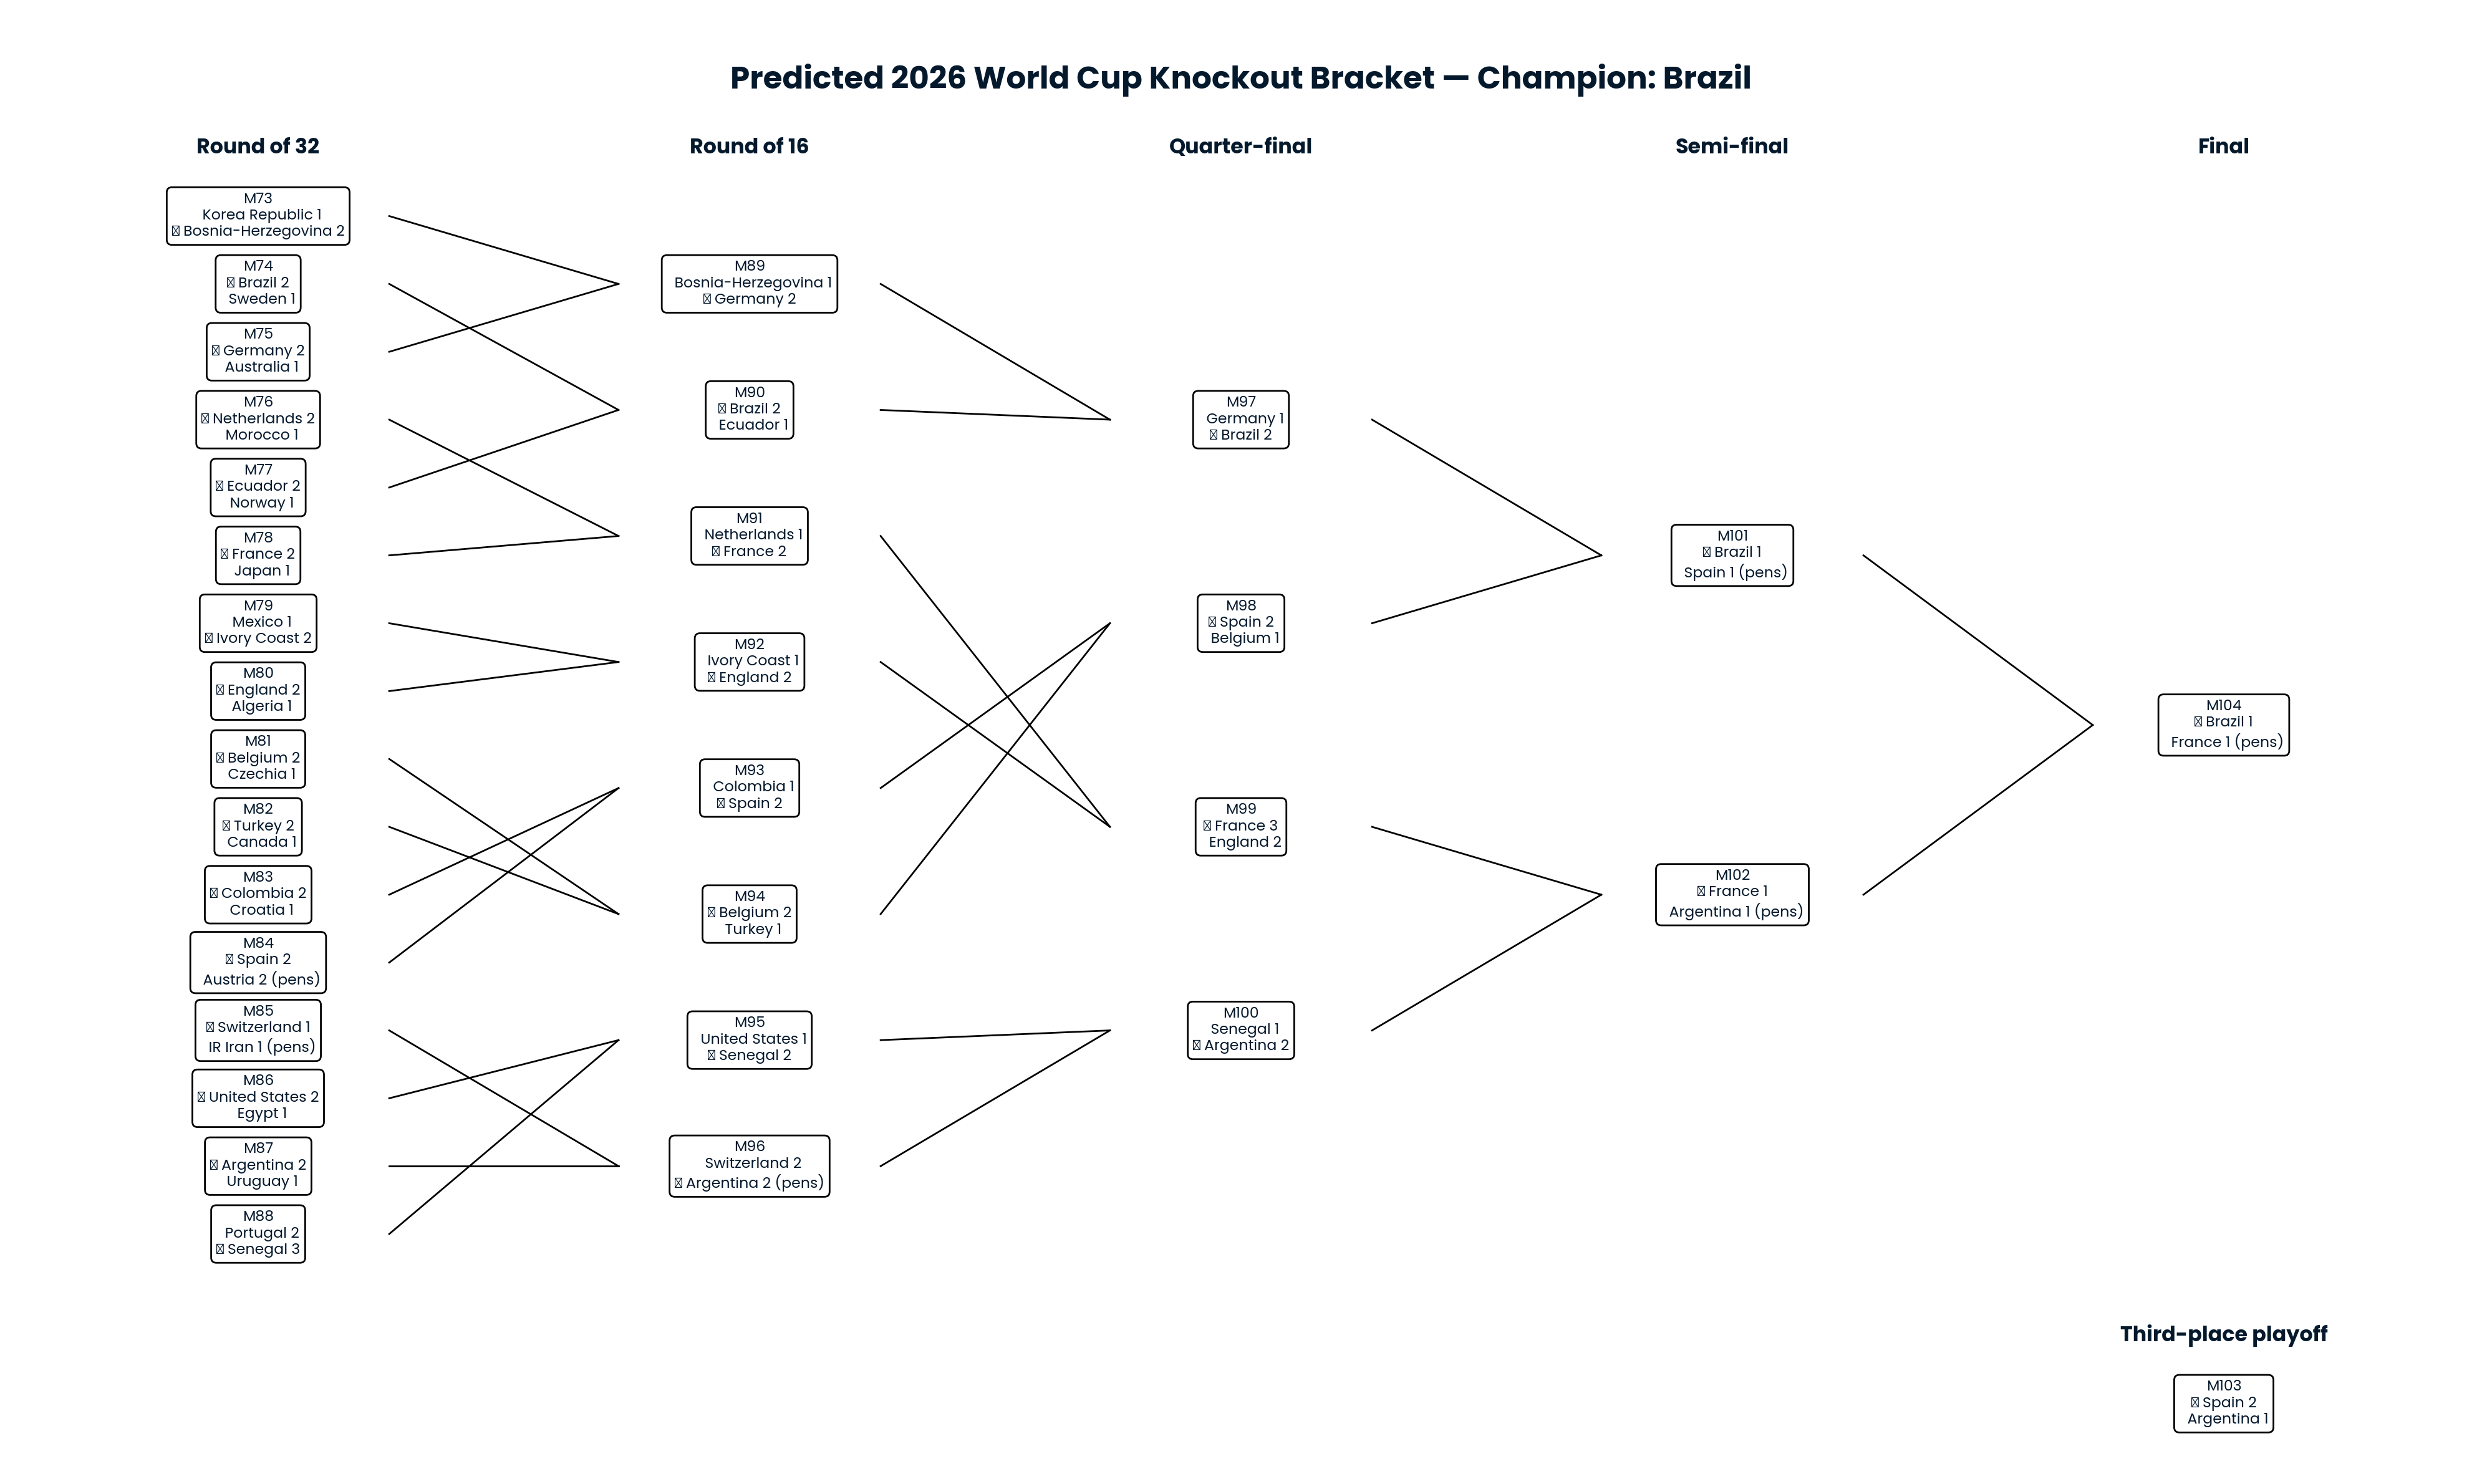


Champion: Brazil

ROUND OF 32
M73: Korea Republic 1-2 Bosnia-Herzegovina → Winner: Bosnia-Herzegovina
M74: Brazil 2-1 Sweden → Winner: Brazil
M75: Germany 2-1 Australia → Winner: Germany
M76: Netherlands 2-1 Morocco → Winner: Netherlands
M77: Ecuador 2-1 Norway → Winner: Ecuador
M78: France 2-1 Japan → Winner: France
M79: Mexico 1-2 Ivory Coast → Winner: Ivory Coast
M80: England 2-1 Algeria → Winner: England
M81: Belgium 2-1 Czechia → Winner: Belgium
M82: Turkey 2-1 Canada → Winner: Turkey
M83: Colombia 2-1 Croatia → Winner: Colombia
M84: Spain 2-2 Austria → Winner: Spain on pens
M85: Switzerland 1-1 IR Iran → Winner: Switzerland on pens
M86: United States 2-1 Egypt → Winner: United States
M87: Argentina 2-1 Uruguay → Winner: Argentina
M88: Portugal 2-3 Senegal → Winner: Senegal

ROUND OF 16
M89: Bosnia-Herzegovina 1-2 Germany → Winner: Germany
M90: Brazil 2-1 Ecuador → Winner: Brazil
M91: Netherlands 1-2 France → Winner: France
M92: Ivory Coast 1-2 England → Winner: England
M93: Colo

In [129]:
# ============================================================
# FIXED FINAL CLEAN KNOCKOUT BRACKET VISUALIZER
# Handles Final + Third-place playoff correctly
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

final_champion = champion_df.iloc[0]["team"]
print("Visualizing bracket for champion:", final_champion)

final_knockout_for_submission = None

for ko_try in all_knockouts:
    champ = ko_try[ko_try["round"] == "Final"].iloc[0]["winner"]
    if champ == final_champion:
        final_knockout_for_submission = ko_try.copy()
        break

if final_knockout_for_submission is None:
    raise ValueError("No knockout bracket found for selected champion.")

ko = final_knockout_for_submission.sort_values("match_id").reset_index(drop=True)

def match_label(row):
    h = row["home_team"]
    a = row["away_team"]
    hg = int(row["home_goals"])
    ag = int(row["away_goals"])
    w = row["winner"]
    pens = " (pens)" if bool(row["penalties"]) else ""

    if w == h:
        return f"★ {h} {hg}\n  {a} {ag}{pens}"
    else:
        return f"  {h} {hg}\n★ {a} {ag}{pens}"

rounds_main = [
    "Round of 32",
    "Round of 16",
    "Quarter-final",
    "Semi-final",
    "Final"
]

x_positions = {
    "Round of 32": 0,
    "Round of 16": 3,
    "Quarter-final": 6,
    "Semi-final": 9,
    "Final": 12
}

y_positions_by_round = {
    "Round of 32": np.linspace(30, 0, 16),
    "Round of 16": np.linspace(28, 2, 8),
    "Quarter-final": np.linspace(24, 6, 4),
    "Semi-final": np.linspace(20, 10, 2),
    "Final": np.array([15])
}

match_positions = {}

fig, ax = plt.subplots(figsize=(20, 12))
ax.axis("off")

ax.text(
    6,
    34,
    f"Predicted 2026 World Cup Knockout Bracket — Champion: {final_champion}",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold"
)

# Draw main bracket boxes only, excluding third-place playoff
for rnd in rounds_main:
    games = ko[ko["round"] == rnd].sort_values("match_id").reset_index(drop=True)
    x = x_positions[rnd]
    ys = y_positions_by_round[rnd]

    ax.text(
        x,
        32,
        rnd,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

    for i, (_, row) in enumerate(games.iterrows()):
        y = ys[i]
        mid = int(row["match_id"])
        match_positions[mid] = (x, y)

        ax.text(
            x,
            y,
            f"M{mid}\n{match_label(row)}",
            ha="center",
            va="center",
            fontsize=8.5,
            bbox=dict(
                boxstyle="round,pad=0.35",
                facecolor="white",
                edgecolor="black",
                linewidth=1
            )
        )

# Draw connectors only for matches present in main bracket positions
main_ko = ko[ko["round"].isin(rounds_main)].copy()

for _, row in main_ko.iterrows():
    current_id = int(row["match_id"])

    if current_id not in match_positions:
        continue

    current_x, current_y = match_positions[current_id]

    for slot in [row["slot_home"], row["slot_away"]]:
        if isinstance(slot, str) and slot.startswith("Winner Match"):
            prev_id = int(slot.replace("Winner Match ", ""))

            if prev_id in match_positions:
                prev_x, prev_y = match_positions[prev_id]

                ax.plot(
                    [prev_x + 0.8, current_x - 0.8],
                    [prev_y, current_y],
                    linewidth=1,
                    color="black"
                )

# Third-place playoff separately
third = ko[ko["round"] == "Third-place playoff"]

if len(third) == 1:
    row = third.iloc[0]

    ax.text(
        12,
        -3,
        "Third-place playoff",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

    ax.text(
        12,
        -5,
        f"M{int(row['match_id'])}\n{match_label(row)}",
        ha="center",
        va="center",
        fontsize=8.5,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="black",
            linewidth=1
        )
    )

ax.set_xlim(-1.5, 13.5)
ax.set_ylim(-7, 36)

plt.tight_layout()
plt.show()

print("\nChampion:", final_champion)

for rnd in rounds_main + ["Third-place playoff"]:
    print("\n" + "=" * 70)
    print(rnd.upper())
    print("=" * 70)

    games = ko[ko["round"] == rnd].sort_values("match_id")

    for _, row in games.iterrows():
        print(
            f"M{int(row['match_id'])}: "
            f"{row['home_team']} {int(row['home_goals'])}-{int(row['away_goals'])} {row['away_team']} "
            f"→ Winner: {row['winner']}"
            f"{' on pens' if bool(row['penalties']) else ''}"
        )

In [130]:
# ============================================================
# FINAL EXPORT USING SELECTED BRACKET
# ============================================================

group_predictions = create_group_predictions(fixtures)

knockout_predictions = final_knockout_for_submission.copy()

final_knockout_rows = []

for _, row in knockout_predictions.iterrows():
    corners, yellows, reds = cards_corners_for_match(
        row["home_team"],
        row["away_team"]
    )

    final_knockout_rows.append({
        "match_id": int(row["match_id"]),
        "round": row["round"],
        "home_team": row["home_team"],
        "away_team": row["away_team"],
        "home_goals": int(row["home_goals"]),
        "away_goals": int(row["away_goals"]),
        "winner": "home" if row["winner"] == row["home_team"] else "away",
        "penalties": bool(row["penalties"]),
        "corners": int(corners),
        "yellow_cards": int(yellows),
        "red_cards": int(reds)
    })

final_knockout_predictions = pd.DataFrame(final_knockout_rows)

group_predictions.to_csv(ROOT / "final_group_predictions.csv", index=False)
final_knockout_predictions.to_csv(ROOT / "final_knockout_predictions.csv", index=False)

print("Saved:")
print(ROOT / "final_group_predictions.csv")
print(ROOT / "final_knockout_predictions.csv")

print("Group:", group_predictions.shape)
print("Knockout:", final_knockout_predictions.shape)

display(group_predictions.head())
display(final_knockout_predictions)

Saved:
/work/files/workspace/final_group_predictions.csv
/work/files/workspace/final_knockout_predictions.csv
Group: (72, 9)
Knockout: (32, 11)


,match_id,home_team,away_team,home_goals,away_goals,winner,corners,yellow_cards,red_cards
0,1,Mexico,South Africa,2,1,home,9,4,0
1,2,Korea Republic,Czechia,2,1,home,9,4,0
2,3,Canada,Bosnia-Herzegovina,1,2,away,9,4,0
3,4,United States,Paraguay,2,1,home,9,4,0
4,5,Australia,Turkey,1,2,away,9,4,0


,match_id,round,home_team,away_team,home_goals,away_goals,winner,penalties,corners,yellow_cards,red_cards
0,73,Round of 32,Korea Republic,Bosnia-Herzegovina,1,2,away,False,9,4,0
1,74,Round of 32,Brazil,Sweden,2,1,home,False,9,5,0
2,75,Round of 32,Germany,Australia,2,1,home,False,9,4,0
3,76,Round of 32,Netherlands,Morocco,2,1,home,False,9,4,0
4,77,Round of 32,Ecuador,Norway,2,1,home,False,9,4,0
5,78,Round of 32,France,Japan,2,1,home,False,9,5,0
6,79,Round of 32,Mexico,Ivory Coast,1,2,away,False,9,4,0
7,80,Round of 32,England,Algeria,2,1,home,False,10,5,0
8,81,Round of 32,Belgium,Czechia,2,1,home,False,9,4,0
9,82,Round of 32,Turkey,Canada,2,1,home,False,9,4,0


In [133]:
# ============================================================
# RECREATE FINAL PREDICTIONS + FILL ORIGINAL DATA CSVs
# ============================================================

from pathlib import Path
import pandas as pd
import shutil

ROOT = Path("/work/files/workspace")
DATA_DIR = ROOT / "data"

# ----------------------------
# 1. Recreate final_group_predictions
# ----------------------------

final_group_predictions = create_group_predictions(fixtures)

# ----------------------------
# 2. Recreate final_knockout_predictions
# ----------------------------

knockout_predictions = final_knockout_for_submission.copy()

final_knockout_rows = []

for _, row in knockout_predictions.iterrows():
    corners, yellows, reds = cards_corners_for_match(
        row["home_team"],
        row["away_team"]
    )

    final_knockout_rows.append({
        "match_id": int(row["match_id"]),
        "round": row["round"],
        "home_team": row["home_team"],
        "away_team": row["away_team"],
        "home_goals": int(row["home_goals"]),
        "away_goals": int(row["away_goals"]),
        "winner": "home" if row["winner"] == row["home_team"] else "away",
        "penalties": bool(row["penalties"]),
        "corners": int(corners),
        "yellow_cards": int(yellows),
        "red_cards": int(reds)
    })

final_knockout_predictions = pd.DataFrame(final_knockout_rows)

# ----------------------------
# 3. Backup original files
# ----------------------------

if not (DATA_DIR / "group_fixtures_BACKUP.csv").exists():
    shutil.copy(DATA_DIR / "group_fixtures.csv", DATA_DIR / "group_fixtures_BACKUP.csv")

if not (DATA_DIR / "knockout_slots_BACKUP.csv").exists():
    shutil.copy(DATA_DIR / "knockout_slots.csv", DATA_DIR / "knockout_slots_BACKUP.csv")

# ----------------------------
# 4. Reload original clean templates from backup
# ----------------------------

group_template = pd.read_csv(DATA_DIR / "group_fixtures_BACKUP.csv")
knockout_template = pd.read_csv(DATA_DIR / "knockout_slots_BACKUP.csv")

# ----------------------------
# 5. Fill group_fixtures.csv
# ----------------------------

group_template = group_template.drop(
    columns=[
        c for c in [
            "predicted_home_goals",
            "predicted_away_goals",
            "corners",
            "yellow_cards",
            "red_cards",
            "winning_team"
        ]
        if c in group_template.columns
    ],
    errors="ignore"
)

gp_for_merge = final_group_predictions.rename(columns={
    "home_goals": "predicted_home_goals",
    "away_goals": "predicted_away_goals",
    "winner": "winning_team"
})[[
    "match_id",
    "predicted_home_goals",
    "predicted_away_goals",
    "corners",
    "yellow_cards",
    "red_cards",
    "winning_team"
]]

group_submit = group_template.merge(
    gp_for_merge,
    on="match_id",
    how="left"
)

# ----------------------------
# 6. Fill knockout_slots.csv
# ----------------------------

knockout_template = knockout_template.drop(
    columns=[
        c for c in [
            "home_team",
            "away_team",
            "predicted_home_goals",
            "predicted_away_goals",
            "corners",
            "yellow_cards",
            "red_cards",
            "match_winner",
            "penalties"
        ]
        if c in knockout_template.columns
    ],
    errors="ignore"
)

kp_for_merge = final_knockout_predictions.rename(columns={
    "home_goals": "predicted_home_goals",
    "away_goals": "predicted_away_goals",
    "winner": "match_winner"
})[[
    "match_id",
    "home_team",
    "away_team",
    "predicted_home_goals",
    "predicted_away_goals",
    "corners",
    "yellow_cards",
    "red_cards",
    "match_winner",
    "penalties"
]]

knockout_submit = knockout_template.merge(
    kp_for_merge,
    on="match_id",
    how="left"
)

# ----------------------------
# 7. Validation
# ----------------------------

print("Group submit shape:", group_submit.shape)
print("Knockout submit shape:", knockout_submit.shape)

print("\nMissing group values:")
print(group_submit[[
    "predicted_home_goals",
    "predicted_away_goals",
    "corners",
    "yellow_cards",
    "red_cards",
    "winning_team"
]].isna().sum())

print("\nMissing knockout values:")
print(knockout_submit[[
    "home_team",
    "away_team",
    "predicted_home_goals",
    "predicted_away_goals",
    "corners",
    "yellow_cards",
    "red_cards",
    "match_winner",
    "penalties"
]].isna().sum())

assert group_submit["match_id"].nunique() == 72
assert knockout_submit["match_id"].nunique() == 32
assert group_submit[[
    "predicted_home_goals",
    "predicted_away_goals",
    "corners",
    "yellow_cards",
    "red_cards",
    "winning_team"
]].isna().sum().sum() == 0
assert knockout_submit[[
    "home_team",
    "away_team",
    "predicted_home_goals",
    "predicted_away_goals",
    "corners",
    "yellow_cards",
    "red_cards",
    "match_winner",
    "penalties"
]].isna().sum().sum() == 0

# ----------------------------
# 8. Save directly over original data files + copies
# ----------------------------

group_submit.to_csv(DATA_DIR / "group_fixtures.csv", index=False)
knockout_submit.to_csv(DATA_DIR / "knockout_slots.csv", index=False)

group_submit.to_csv(ROOT / "submission_group_fixtures.csv", index=False)
knockout_submit.to_csv(ROOT / "submission_knockout_slots.csv", index=False)

print("\n✅ DONE. Submit these:")
print(DATA_DIR / "group_fixtures.csv")
print(DATA_DIR / "knockout_slots.csv")

display(group_submit.head())
display(knockout_submit.head())

Group submit shape: (72, 12)
Knockout submit shape: (32, 16)

Missing group values:
predicted_home_goals    0
predicted_away_goals    0
corners                 0
yellow_cards            0
red_cards               0
winning_team            0
dtype: int64

Missing knockout values:
home_team               0
away_team               0
predicted_home_goals    0
predicted_away_goals    0
corners                 0
yellow_cards            0
red_cards               0
match_winner            0
penalties               0
dtype: int64

✅ DONE. Submit these:
/work/files/workspace/data/group_fixtures.csv
/work/files/workspace/data/knockout_slots.csv


,match_id,group,home_team,away_team,date_utc,venue,predicted_home_goals,predicted_away_goals,corners,yellow_cards,red_cards,winning_team
0,1,A,Mexico,South Africa,2026-06-11T19:00:00Z,"Estadio Azteca, Mexico City",2,1,9,4,0,home
1,2,A,South Korea,UEFA Playoff D,2026-06-12T02:00:00Z,"Estadio Akron, Guadalajara",2,1,9,4,0,home
2,3,B,Canada,UEFA Playoff A,2026-06-12T19:00:00Z,"BMO Field, Toronto",1,2,9,4,0,away
3,4,D,USA,Paraguay,2026-06-13T01:00:00Z,"SoFi Stadium, Los Angeles",2,1,9,4,0,home
4,5,D,Australia,UEFA Playoff C,2026-06-13T04:00:00Z,"BC Place, Vancouver",1,2,9,4,0,away


,match_id,round,multiplier,date_utc,venue,slot_home,slot_away,home_team,away_team,predicted_home_goals,predicted_away_goals,corners,yellow_cards,red_cards,match_winner,penalties
0,73,Round of 32,1,2026-06-28T19:00:00Z,"SoFi Stadium, Los Angeles",Runner-up Group A,Runner-up Group B,Korea Republic,Bosnia-Herzegovina,1,2,9,4,0,away,False
1,74,Round of 32,1,2026-06-29T17:00:00Z,"NRG Stadium, Houston",Winner Group C,Runner-up Group F,Brazil,Sweden,2,1,9,5,0,home,False
2,75,Round of 32,1,2026-06-29T20:30:00Z,"Gillette Stadium, Boston",Winner Group E,Best 3rd (Groups A/B/C/D/F),Germany,Australia,2,1,9,4,0,home,False
3,76,Round of 32,1,2026-06-30T01:00:00Z,"Estadio BBVA, Monterrey",Winner Group F,Runner-up Group C,Netherlands,Morocco,2,1,9,4,0,home,False
4,77,Round of 32,1,2026-06-30T17:00:00Z,"AT&T Stadium, Dallas",Runner-up Group E,Runner-up Group I,Ecuador,Norway,2,1,9,4,0,home,False
